In [11]:
import numpy as np
from matplotlib import pyplot as plt

Define the problem parameters. 


In [12]:
A = np.array([[1, 3], [3, 1]]) # low dimensions to plot it, you can test larger sizes
b = np.zeros(2)

lmbda = 0.5


The function to be minimized is $\frac{1}{2}\|Ax-b\|_2^2 + \lambda \|x\|_1$

In [13]:
f = lambda x: 0.5 * np.sum((A @ x - b) ** 2) + lmbda * np.sum(np.abs(x))

# derivative of f from matrix calculus
df = lambda x: A.T @ (A @ x) - A.T @ b


Plot the function

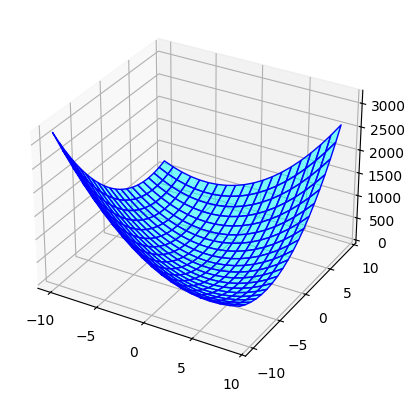

In [14]:
# this function has been prepared only for the visualization sake, no need to go through this but it renders some nice
# graphics :)
F = lambda r1, r2: (r1 * A[0, 0] + r2 * A[0, 1] - b[0]) ** 2 + (r1 * A[1, 0] + r2 * A[1,1] - b[1]) ** 2 + lmbda * (np.abs(r1) + np.abs(r2))
xx, yy = np.meshgrid(np.arange(-10, 10, 1), np.arange(-10, 10, 1))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])

Parameters of ISTA

In [15]:
TOL_GRAD_NORM = 1e-4
MAX_ITER = 1e3
TOL_DIST_X = 1e-3
alpha = 0.05
# optimal value for alpha
alpha = 1 / np.max(np.linalg.eigvals(A.T@A))

Initialization: test different inizializations, the function is convex, you always converge to the same solution

In [16]:
x = np.array([-7, 12])

grad_norm = 1e10
distanceX = 1e10

# initialize the list with all the estimates
all_x = [x]


Main loop

In [17]:
def soft_thresholding(x):    
    # perform soft thresholding of x
    for i, component in enumerate(x):
    # Minimum at the right 
        if component > lmbda:
            x[i] += - lmbda
        # Minimum in the left
        elif component < -lmbda:
            x[i] += lmbda
        # 0
        else:
            x[i] =0
    return x
cnt = 0

while cnt < MAX_ITER and distanceX > TOL_DIST_X and grad_norm > TOL_GRAD_NORM:

  # compute the argument of the proximal operator
  x = x - alpha * df(x)

  # perform soft thresholding of x
  x = soft_thresholding(x)

  # compute the norm of the gradient for the stopping criteria
  grad_norm = np.linalg.norm(df(x))

  # compute the distance between two consecutive iterates for the stopping criteria
  distanceX = np.linalg.norm(all_x[-1] - x)

  # store the estimate
  all_x.append(x)
  cnt += 1


Plot all the estimates

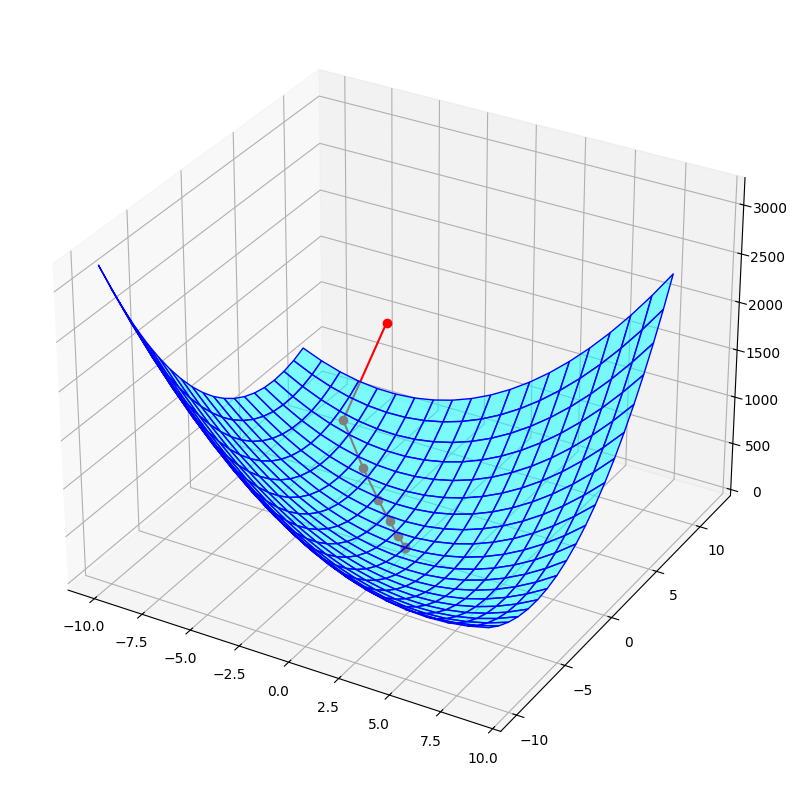

In [18]:
# plot the new estimate
xxplot = [x[0] for x in all_x]
yyplot = [x[1] for x in all_x]
zzplot = F(np.array(xxplot), np.array(yyplot))

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.plot_surface(xx, yy, F(xx, yy), edgecolor=[0, 0, 1], alpha=0.5, facecolor=[0, 1, 1])
ax.plot3D(xxplot, yyplot, zzplot, 'r-o')

In [19]:
print(f'nr of iteration of ISTA (before stopping criteria met): {cnt}\n')
for i in range(cnt):
    print(f"Iteration number: {i}")
    print(f'\tSolution of ISTA: [{all_x[i][0]:.4f}, {all_x[i][1]:.4f}]')
    print(f'\tValue of the functional: {f(all_x[i]):.4f}\n')

nr of iteration of ISTA (before stopping criteria met): 7

Iteration number: 0
	Solution of ISTA: [-7.0000, 12.0000]
	Value of the functional: 470.5000

Iteration number: 1
	Solution of ISTA: [-6.6250, 6.6250]
	Value of the functional: 182.1875

Iteration number: 2
	Solution of ISTA: [-4.4688, 4.4688]
	Value of the functional: 84.3477

Iteration number: 3
	Solution of ISTA: [-2.8516, 2.8516]
	Value of the functional: 35.3772

Iteration number: 4
	Solution of ISTA: [-1.6387, 1.6387]
	Value of the functional: 12.3797

Iteration number: 5
	Solution of ISTA: [-0.7290, 0.7290]
	Value of the functional: 2.8548

Iteration number: 6
	Solution of ISTA: [-0.0468, 0.0468]
	Value of the functional: 0.0555

